initializing ocelot...


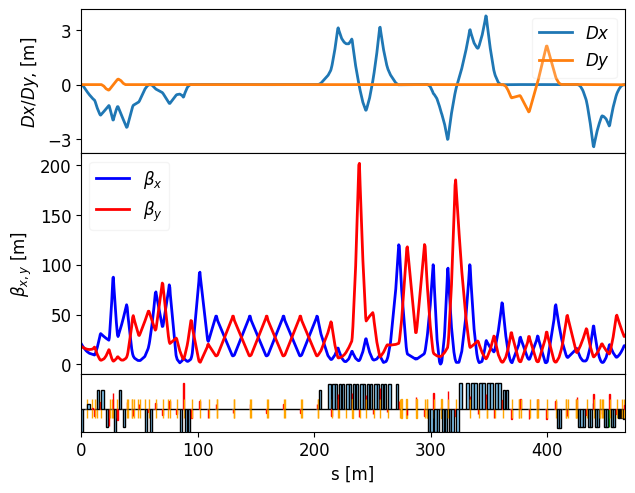

In [1]:
from ocelot import *
from ocelot.cpbd.elements import *
from ocelot.gui.accelerator import *
from ocelot.cpbd.track import track_debug
import matplotlib.pyplot as plt


from bte import *

#lat = MagneticLattice(lattice_list[0:380])
#lat = MagneticLattice(lattice_list[320:540])
lat = MagneticLattice(lattice_list)


energy = 7 # GeV  #why?
tw0 = Twiss()
tw0.alpha_x = AX
tw0.beta_x = BX

tw0.alpha_y = AY
tw0.beta_y = BY
tw0.E = energy
tw0.emit_xn = EMITX 
tw0.emit_yn = EMITY
tw0.emit_x = EMITX   / energy * 0.511e-3
tw0.emit_y = EMITY / energy * 0.511e-3

tws = twiss(lat,tw0)

plot_opt_func(lat, tws,legend=False, grid=False, top_plot=['Dx','Dy'])

In [2]:
# start_index = next(i for i, el in enumerate(lattice_list) if el.id == "PA1RFGUN")
# end_index = next(i for i, el in enumerate(lattice_list) if el.id == "L491")

# sub_lat = MagneticLattice(lattice_list[start_index:end_index + 1])

# R = lattice_transfer_map(sub_lat, energy=1.5)
# print("R56 = ", R[4,5]*1000, "mm")


In [3]:
import pickle

# Load the full ParticleArray (including rparticles, q_array, energy, etc.)
with open("p_array_t_LINAC.pkl", "rb") as f:
    p_array = pickle.load(f)

#  confirm:
print("Number of particles loaded:", p_array.n)
print("Beam energy [GeV]:", p_array.E)




Number of particles loaded: 100000
Beam energy [GeV]: 7.210982518804095


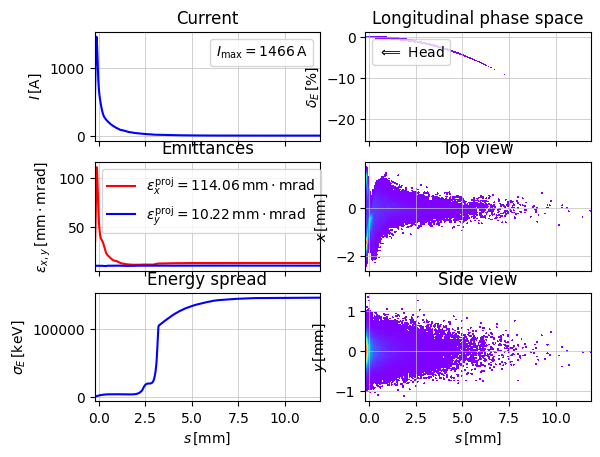

In [4]:
show_e_beam(p_array)

s = 0.100 m, σ_τ = 9.315e-04 s
z = 0.1 / 466.60429345389946. Applied: HookProcesss = 0.200 m, σ_τ = 9.315e-04 s
z = 0.2 / 466.60429345389946. Applied: HookProcesss = 0.300 m, σ_τ = 9.307e-04 s
z = 0.30000000000000004 / 466.60429345389946. Applied: HookProcesss = 0.400 m, σ_τ = 9.298e-04 s
z = 0.4 / 466.60429345389946. Applied: HookProcesss = 0.500 m, σ_τ = 9.288e-04 s
z = 0.5 / 466.60429345389946. Applied: HookProcesss = 0.600 m, σ_τ = 9.278e-04 s
z = 0.6 / 466.60429345389946. Applied: HookProcesss = 0.700 m, σ_τ = 9.267e-04 s
z = 0.7 / 466.60429345389946. Applied: HookProcesss = 0.800 m, σ_τ = 9.256e-04 s
z = 0.7999999999999999 / 466.60429345389946. Applied: HookProcesss = 0.900 m, σ_τ = 9.243e-04 s
z = 0.8999999999999999 / 466.60429345389946. Applied: HookProcesss = 1.000 m, σ_τ = 9.230e-04 s
z = 0.9999999999999999 / 466.60429345389946. Applied: HookProcesss = 1.100 m, σ_τ = 9.215e-04 s
z = 1.0999999999999999 / 466.60429345389946. Applied: HookProcesss = 1.200 m, σ_τ = 9.198e-04 s
z 

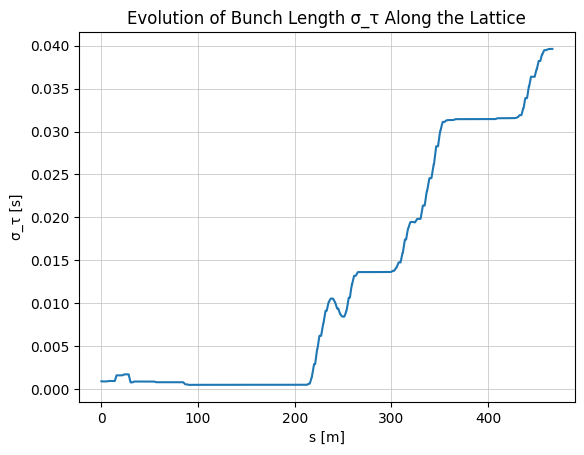

In [5]:
import time
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from ocelot.cpbd.physics_proc import PhysProc

# Create the Navigator
navi = Navigator(lat)
navi.unit_step = 0.1  # high-resolution steps

# CSR example (optional)
csr = CSR(n_bin=500, m_bin=5, sigma_min=.2e-6)
navi.add_physics_proc(csr, CSR_START, CSR_END)

# Define the hook as a physics process
class HookProcess(PhysProc):
    def __init__(self, sigma_tau_list):
        super().__init__()
        self.sigma_tau_list = sigma_tau_list

    def apply(self, p_array, step_size):
        sigma_tau = np.std(p_array.rparticles[4])
        self.sigma_tau_list.append(sigma_tau)
        print(f"s = {self.z0:.3f} m, σ_τ = {sigma_tau:.3e} s")

# Attach the custom hook process
sigma_tau_list = []
hook_proc = HookProcess(sigma_tau_list)
navi.add_physics_proc(hook_proc, lat.sequence[0], lat.sequence[-1])

# Track
p_array_t = deepcopy(p_array)
start = time.time()
tws_track, p_array_t = track(lat, p_array_t, navi)
print("\n time exec:", time.time() - start, "sec")

# Plot
print("sigma_tau_list length:", len(sigma_tau_list))
print("lat.totalLen:", lat.totalLen)

s_axis = np.linspace(0, lat.totalLen, len(sigma_tau_list))
plt.plot(s_axis, sigma_tau_list)
plt.xlabel("s [m]")
plt.ylabel("σ_τ [s]")
plt.title("Evolution of Bunch Length σ_τ Along the Lattice")
plt.grid(True)
plt.show()


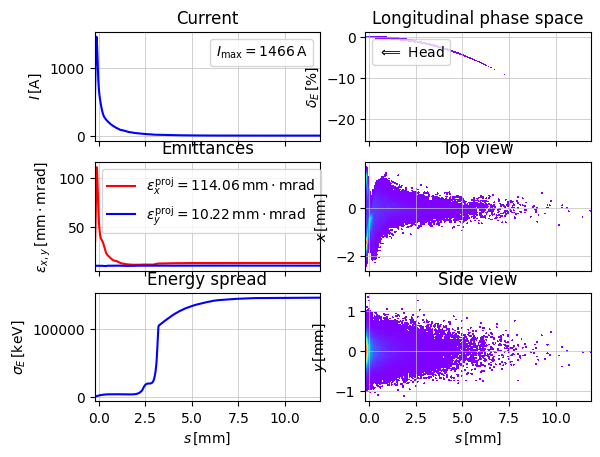

In [6]:
show_e_beam(p_array)

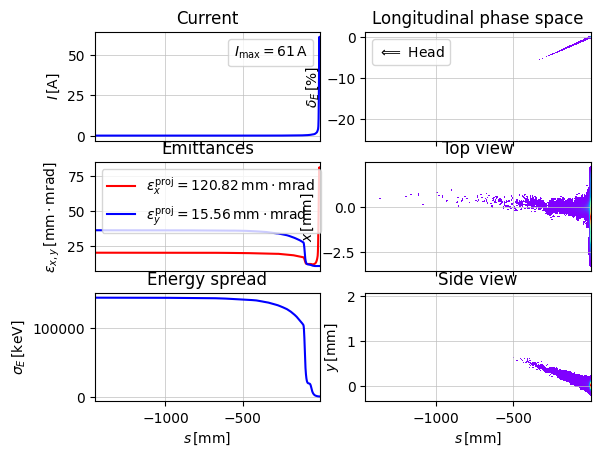

In [7]:
show_e_beam(p_array_t)



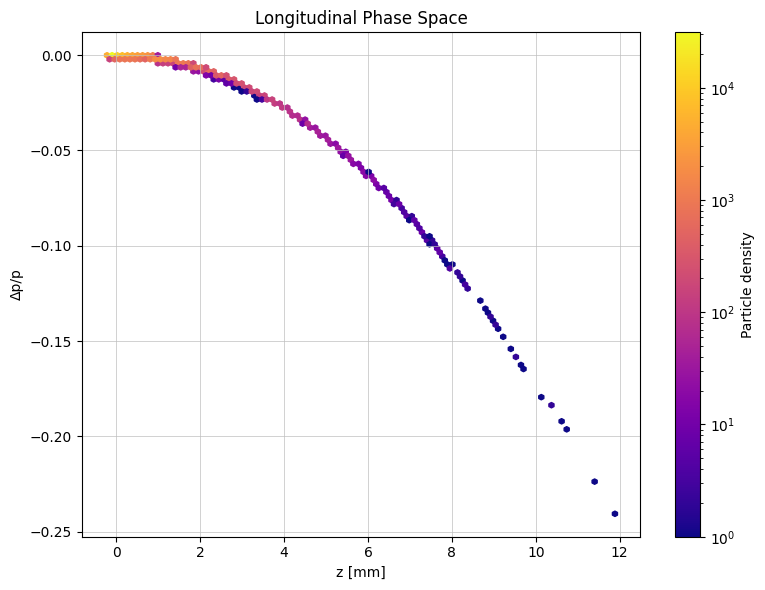

In [ ]:
import matplotlib.pyplot as plt

# Longitudinal phase space: z vs. Δp/p
z = p_array.rparticles[4]   # in meters
dp_p = p_array  .rparticles[5]  # unitless

plt.figure(figsize=(8,6))
plt.hexbin(z * 1e3, dp_p, gridsize=100, cmap='plasma', bins='log')  # convert z to mm for better readability
plt.colorbar(label='Particle density')
plt.xlabel("z [mm]")
plt.ylabel("Δp/p")
plt.title("Longitudinal Phase Space")
plt.grid(True)
plt.tight_layout()
plt.show()

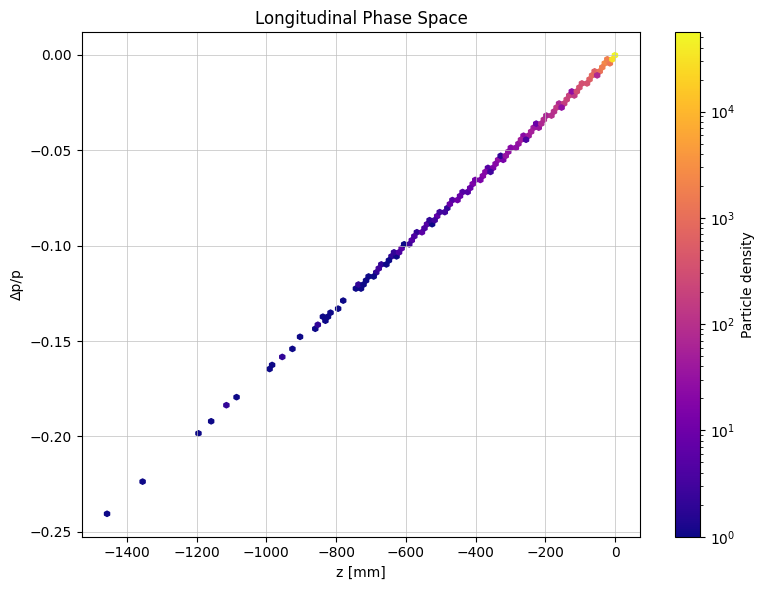

In [9]:
import matplotlib.pyplot as plt

# Longitudinal phase space: z vs. Δp/p
z = p_array_t.rparticles[4]   # in meters
dp_p = p_array_t.rparticles[5]  # unitless

plt.figure(figsize=(8,6))
plt.hexbin(z * 1e3, dp_p, gridsize=100, cmap='plasma', bins='log')  # convert z to mm for better readability
plt.colorbar(label='Particle density')
plt.xlabel("z [mm]")
plt.ylabel("Δp/p")
plt.title("Longitudinal Phase Space")
plt.grid(True)
plt.tight_layout()
plt.show()

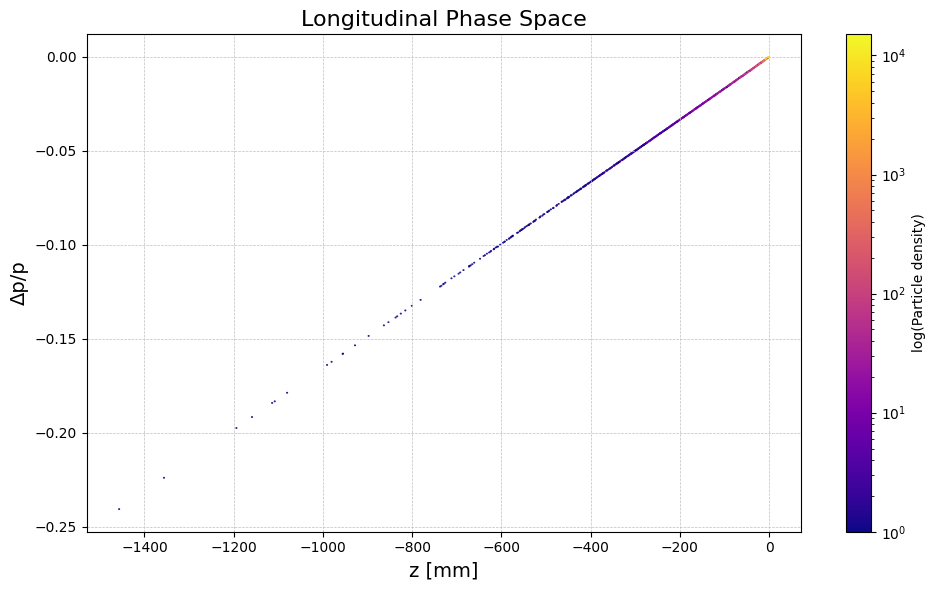

In [10]:
# Longitudinal phase space: z vs. Δp/p
z = p_array_t.rparticles[4]   # in meters
dp_p = p_array_t.rparticles[5]  # unitless

plt.figure(figsize=(10, 6))

hb = plt.hexbin(z * 1e3, dp_p, gridsize=1000, cmap='plasma', bins='log')  # log scale improves contrast
plt.colorbar(hb, label='log(Particle density)')

plt.xlabel("z [mm]", fontsize=14)
#plt.xlim(-1,2)
#plt.ylim(-0.02,0.02)
plt.ylabel("Δp/p", fontsize=14)
plt.title("Longitudinal Phase Space", fontsize=16)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

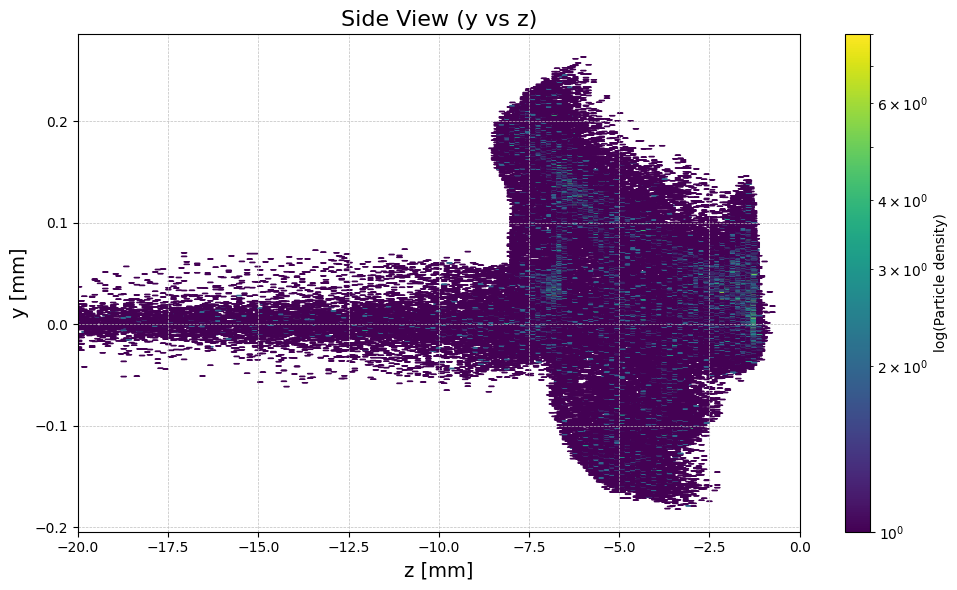

In [11]:
y = p_array_t.rparticles[1]  # in meters

plt.figure(figsize=(10, 6))
hb = plt.hexbin(z * 1e3, y * 1e3, gridsize=10000, cmap='viridis', bins='log')
plt.colorbar(hb, label='log(Particle density)')

plt.xlabel("z [mm]", fontsize=14)
plt.ylabel("y [mm]", fontsize=14)
plt.xlim(-20,0)
plt.title("Side View (y vs z)", fontsize=16)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


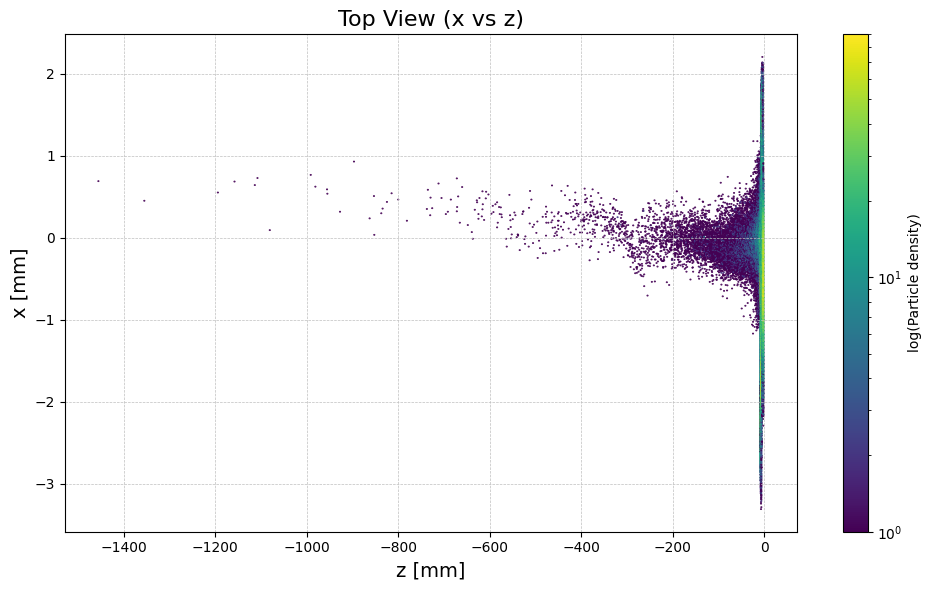

In [12]:
x = p_array_t.rparticles[0]  # in meters

plt.figure(figsize=(10, 6))
hb = plt.hexbin(z * 1e3, x * 1e3, gridsize=1000, cmap='viridis', bins='log')
plt.colorbar(hb, label='log(Particle density)')

plt.xlabel("z [mm]", fontsize=14)
plt.ylabel("x [mm]", fontsize=14)
plt.title("Top View (x vs z)", fontsize=16)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()
